I. Impliment linear regression


In [1]:
from __future__ import division, print_function, unicode_literals
import numpy as np
import matplotlib.pyplot as plt

-33.735410206298866 0.5592049619425978


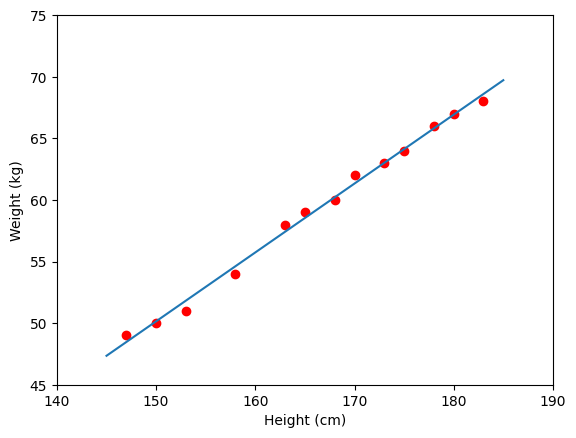

In [9]:
# nhap input
X = np.array([[147, 150, 153, 158, 163, 165, 168, 170, 173, 175, 178, 180, 183]]).T
y = np.array([[ 49, 50, 51,  54, 58, 59, 60, 62, 63, 64, 66, 67, 68]]).T

# tao Xbar
one = np.ones((X.shape[0],1))
Xbar = np.concatenate((one,X), axis = 1) #them cot 1 de co the tinh dc W0

A = np.dot(Xbar.T, Xbar) # tinh X^TX
B = np.dot (Xbar.T, y) # tinh X^T.y
W = np.dot(np.linalg.pinv(A),B)

w0 = W[0][0] # lay w0,w1
w1 = W[1][0]

x0 = np.linspace(145, 185, 100)
y0 = w0 + w1*x0

print(w0,w1)

# ve hinh
plt.plot(X.T, y.T, 'ro')     # data 
plt.plot(x0, y0)               # duong ve
plt.axis([140, 190, 45, 75])
plt.xlabel('Height (cm)')
plt.ylabel('Weight (kg)')
plt.show()






I. implement logistic regression

[[-4.092695  ]
 [ 1.55277242]]


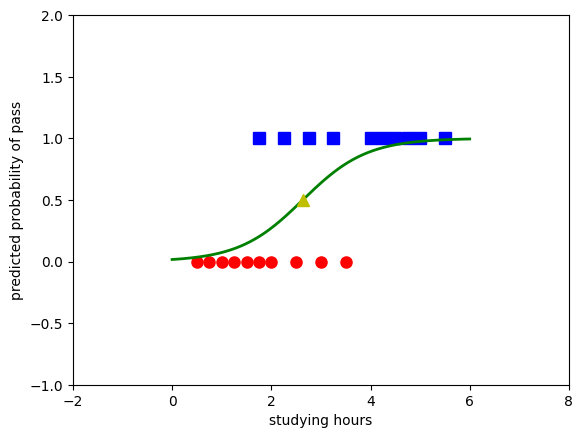

In [4]:
# To support both python 2 and python 3
from __future__ import division, print_function, unicode_literals
import numpy as np 
import matplotlib.pyplot as plt
np.random.seed(2)

X = np.array([[0.50, 0.75, 1.00, 1.25, 1.50, 1.75, 1.75, 2.00, 2.25, 2.50, 
              2.75, 3.00, 3.25, 3.50, 4.00, 4.25, 4.50, 4.75, 5.00, 5.50]])
y = np.array([0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1])

# extended data 
X = np.concatenate((np.ones((1, X.shape[1])), X), axis = 0)

def sigmoid(s):
    return 1/(1 + np.exp(-s))

def logistic_sigmoid_regression(X, y, w_init, eta, tol = 1e-4, max_count = 10000):
    w = [w_init]    
    it = 0
    N = X.shape[1]
    d = X.shape[0]
    count = 0
    check_w_after = 20
    while count < max_count:
        # mix data 
        mix_id = np.random.permutation(N)
        for i in mix_id:
            xi = X[:, i].reshape(d, 1)
            yi = y[i]
            zi = sigmoid(np.dot(w[-1].T, xi))
            w_new = w[-1] + eta*(yi - zi)*xi
            count += 1
            # stopping criteria
            if count%check_w_after == 0:                
                if np.linalg.norm(w_new - w[-check_w_after]) < tol:
                    return w
            w.append(w_new)
    return w
eta = .05 
d = X.shape[0]
w_init = np.random.randn(d, 1)

w = logistic_sigmoid_regression(X, y, w_init, eta)
print(w[-1])

X0 = X[1, np.where(y == 0)][0]
y0 = y[np.where(y == 0)]
X1 = X[1, np.where(y == 1)][0]
y1 = y[np.where(y == 1)]

plt.plot(X0, y0, 'ro', markersize = 8)
plt.plot(X1, y1, 'bs', markersize = 8)

xx = np.linspace(0, 6, 1000)
w0 = w[-1][0][0]
w1 = w[-1][1][0]
threshold = -w0/w1
yy = sigmoid(w0 + w1*xx)
plt.axis([-2, 8, -1, 2])
plt.plot(xx, yy, 'g-', linewidth = 2)
plt.plot(threshold, .5, 'y^', markersize = 8)
plt.xlabel('studying hours')
plt.ylabel('predicted probability of pass')
plt.show()


II. implement linear regression


In [6]:
# -*- coding: utf-8 -*-

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Đọc dữ liệu
data = pd.read_csv('data_linear.csv').values
N = data.shape[0]

# Lấy cột diện tích và giá
x = data[:, 0].reshape(-1, 1)
y = data[:, 1].reshape(-1, 1)

# Vẽ dữ liệu
plt.scatter(x, y)
plt.xlabel('mét vuông')
plt.ylabel('giá')

# Thêm cột 1 để tính bias
x = np.hstack((np.ones((N, 1)), x))

# Khởi tạo trọng số
w = np.array([0., 1.]).reshape(-1, 1)

numOfIteration = 100
cost = np.zeros((numOfIteration, 1))
learning_rate = 0.000001

# Gradient Descent
for i in range(1, numOfIteration):
    
    r = np.dot(x, w) - y
    
    cost[i] = 0.5 * np.sum(r * r)
    
    w[0] -= learning_rate * np.sum(r)
    
    w[1] -= learning_rate * np.sum(np.multiply(r, x[:, 1].reshape(-1, 1)))
    
    print(cost[i])

# Dự đoán
predict = np.dot(x, w)

# Vẽ đường hồi quy
plt.plot((x[0][1], x[N-1][1]), (predict[0], predict[N-1]), 'r')
plt.show()

# Dự đoán giá nhà 50m2
x1 = 50
y1 = w[0] + w[1] * x1
print('Giá nhà cho 50m^2 là : ', y1)

# Lưu trọng số
np.save('weight.npy', w)

# Đọc lại trọng số
w = np.load('weight.npy')

# Linear Regression bằng sklearn
from sklearn.linear_model import LinearRegression

data = pd.read_csv('data_linear.csv').values

x = data[:, 0].reshape(-1, 1)
y = data[:, 1].reshape(-1, 1)

lrg = LinearRegression()

# Train model
lrg.fit(x, y)

# Dự đoán
y_pred = lrg.predict(x)

# Vẽ đường hồi quy
plt.scatter(x, y)
plt.plot((x[0], x[-1]), (y_pred[0], y_pred[-1]), 'r')
plt.show()

# Lưu tham số
np.savez('w2.npz', a=lrg.intercept_, b=lrg.coef_)

# Đọc lại tham số
k = np.load('w2.npz')
lrg.intercept_ = k['a']
lrg.coef_ = k['b']

ModuleNotFoundError: No module named 'pandas'

In [ ]:
python -m pip install pandas